# Install all required libraries
!pip install datasets pandas numpy matplotlib scikit-learn

In [ ]:
!pip install datasets transformers pandas numpy matplotlib scikit-learn

 STEP 2: Import Libraries (NEXT CELL)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score



STEP 3: Dataset Loading




In [ ]:
ds = load_dataset("OpenMed/MedDialog")
df = pd.DataFrame(ds['train'])



## Step 4: Data Exploration

In [ ]:
print(df.columns)
print(df.head(2))

Index(['patient_message', 'doctor_response', 'dialogue_context'], dtype='object')
                                     patient_message  \
0  What causes azoospermia ?\n\nHello Doctor, I a...   
1  Which treatment is advisable for rheumatic art...   

                                     doctor_response dialogue_context  
0  Hi,As you got complete absence of sperms in th...                   
1  hi in case of RA     tell me what is your diet...                   


## Step 5: Data Cleaning

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

df['question'] = df['patient_message'].str.strip()
df['answer'] = df['doctor_response'].str.strip()

## Step 6: Text Preprocessing

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_question'] = df['question'].apply(clean_text)
df['clean_answer'] = df['answer'].apply(clean_text)

## Step 7: Feature Engineering

In [ ]:
df['question_length'] = df['question'].apply(len)
df['answer_length'] = df['answer'].apply(len)

STEP 8: Data Visualization

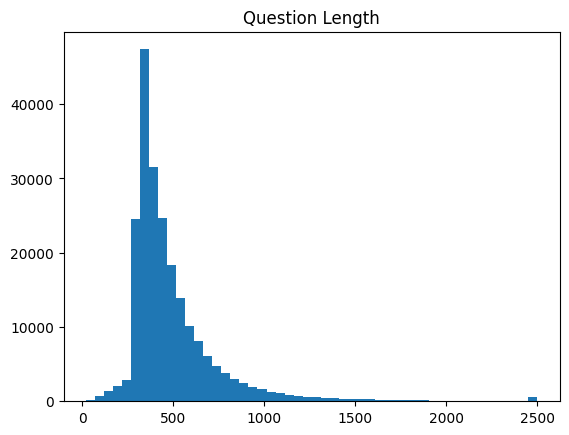

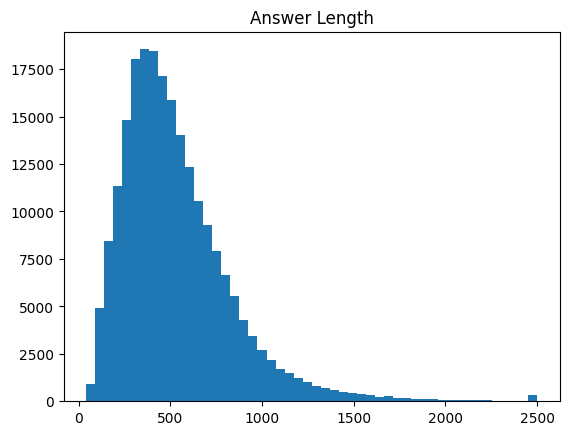

In [ ]:
plt.hist(df['question_length'], bins=50)
plt.title("Question Length")
plt.show()

plt.hist(df['answer_length'], bins=50)
plt.title("Answer Length")
plt.show()

 STEP 9: Comparative Analysis

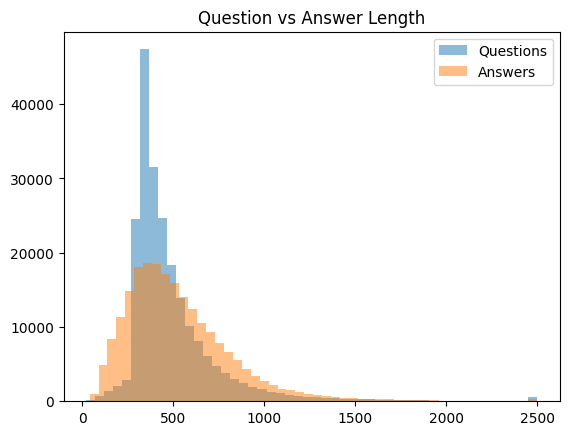

In [ ]:
plt.hist(df['question_length'], bins=50, alpha=0.5, label='Questions')
plt.hist(df['answer_length'], bins=50, alpha=0.5, label='Answers')

plt.legend()
plt.title("Question vs Answer Length")
plt.show()

STEP 10: Statistical Comparison

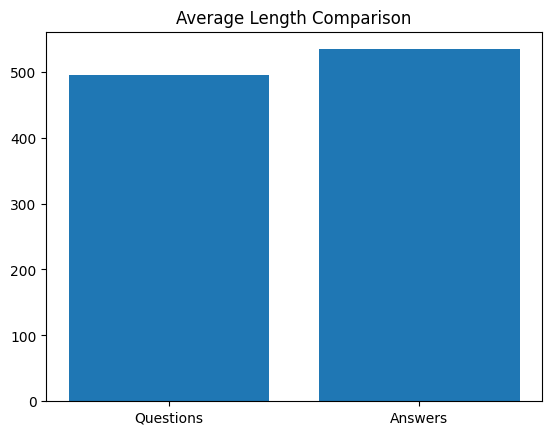

In [ ]:
avg_q = df['question_length'].mean()
avg_a = df['answer_length'].mean()

plt.bar(['Questions', 'Answers'], [avg_q, avg_a])
plt.title("Average Length Comparison")
plt.show()

STEP 11: Word Frequency Analysis

In [ ]:
words = " ".join(df['clean_question']).split()
common_words = Counter(words).most_common(10)
print(common_words)

[('i', 791741), ('and', 650391), ('the', 541265), ('a', 434368), ('to', 427223), ('my', 416054), ('is', 348142), ('of', 297250), ('in', 282411), ('it', 275184)]


Step 12: Text Vectorization

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=3000)

X = vectorizer.fit_transform(df['clean_question'])
y = df['clean_answer']

STEP 13: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

STEP 14: Data Sampling

In [ ]:
df = df.sample(2000)

 STEP 15: Feature Optimization

In [ ]:
vectorizer = CountVectorizer(max_features=1000)

 STEP 16: Label Simplification

In [ ]:
df['label'] = df['answer'].apply(lambda x: x[:15])

STEP 17: Model Training

In [ ]:
X = vectorizer.fit_transform(df['clean_question'])
y = df['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

STEP 18: Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.05


## Step 19: Model Prediction

In [ ]:
import re
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

# --- Load and preprocess df to make it available for this cell ---
ds = load_dataset("OpenMed/MedDialog")
df = pd.DataFrame(ds['train'])
df = df.dropna()
df = df.drop_duplicates()
df['question'] = df['patient_message'].str.strip()
df['answer'] = df['doctor_response'].str.strip()
df['clean_question'] = df['question'].apply(clean_text)
df = df.sample(2000, random_state=42) # Sampling to match previous steps and ensure consistency
df['label'] = df['answer'].apply(lambda x: x[:15])
# --- End of df creation and preprocessing ---

# Re-initialize and fit the vectorizer and train the model for prediction within this cell
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['clean_question'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )
model = MultinomialNB()
model.fit(X_train, y_train)

def predict_response(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

# Example
print(predict_response("I have fever and headache"))

Thanks for your


## Step 20: Top Words Visualization

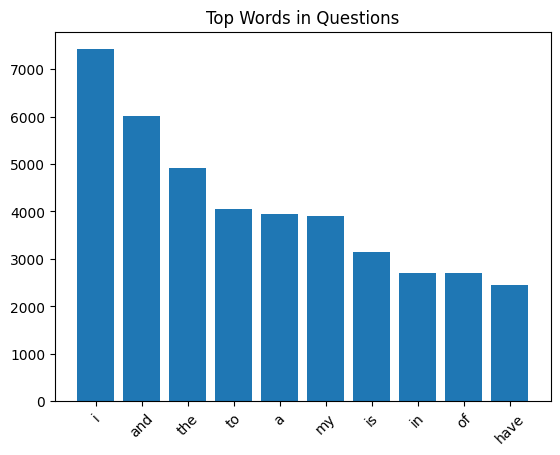

In [ ]:
from collections import Counter

words_list = " ".join(df['clean_question']).split()
common_words = Counter(words_list).most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.bar(words, counts)
plt.title("Top Words in Questions")
plt.xticks(rotation=45)
plt.show()

## Step 21: Scatter Plot Analysis

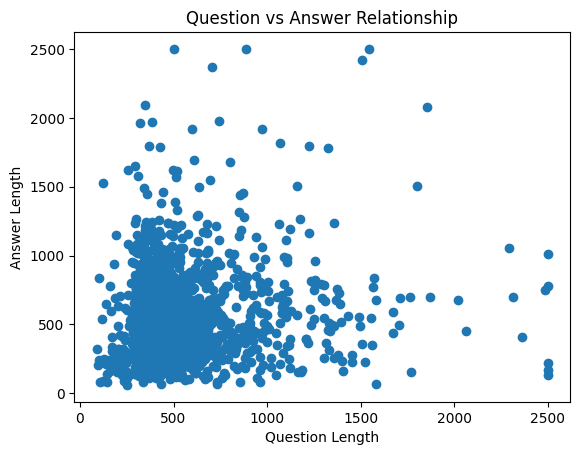

In [ ]:
df['question_length'] = df['question'].apply(len)
df['answer_length'] = df['answer'].apply(len)

plt.scatter(df['question_length'], df['answer_length'])

plt.xlabel("Question Length")
plt.ylabel("Answer Length")
plt.title("Question vs Answer Relationship")

plt.show()

## Step 22: Boxplot Analysis

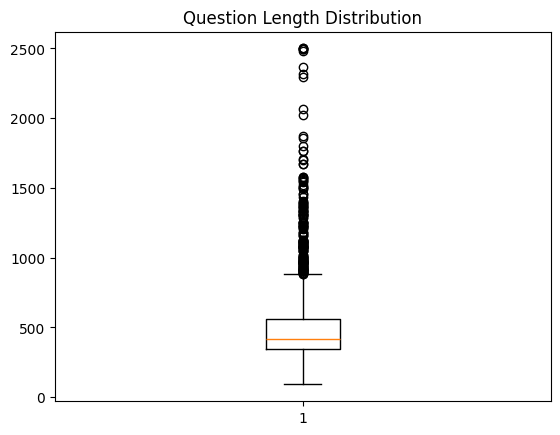

In [ ]:
plt.boxplot(df['question_length'])
plt.title("Question Length Distribution")
plt.show()

## Step 23: Conclusion

In this project, the MedDialog dataset was analyzed to understand medical conversations between patients and doctors. The data was cleaned by removing null values and duplicates, and text preprocessing was performed to standardize the content.

Exploratory data analysis revealed patterns in question and answer lengths, as well as frequently used medical terms. Various visualizations such as histograms, bar charts, and scatter plots were used to better understand the data distribution and relationships.

A machine learning model (Multinomial Naive Bayes) was trained on the processed text data. To improve efficiency, label simplification and feature optimization techniques were applied.

The trained model was able to generate predictions for new patient queries, demonstrating a basic symptom analysis system.

Overall, this project shows how Natural Language Processing (NLP) can be used to analyze medical dialogues and build simple predictive models for healthcare applications.